# Customer Churn Prediction — End-to-End sklearn Pipeline

**Objective:** build a reusable, production-ready pipeline that predicts whether a telecom
customer is going to churn, using the `Pipeline` / `ColumnTransformer` API so preprocessing
and modeling travel together as one object.

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
— 7,043 customers, 20 features (demographics, account info, services subscribed), binary
`Churn` label.

**Approach:**
1. Load + clean the data
2. Build a `ColumnTransformer` for scaling/encoding
3. Wrap Logistic Regression and Random Forest in full pipelines
4. Tune both with `GridSearchCV`
5. Compare on accuracy / precision / recall / F1 / ROC-AUC
6. Export the winning pipeline with `joblib` so it can be dropped into an API later


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import joblib

RANDOM_STATE = 42  # kept constant, so results are reproducible
sns.set_style("whitegrid")


## 1. Load the data

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Data quality check

Two things always trip people up with this dataset:

- `TotalCharges` is read in as text, not a number, it contains 11 blank strings for brand-new
  customers (`tenure == 0`, so of course they haven't paid anything yet).
- The target `Churn` is `Yes`/`No`, not `0`/`1`.

In [4]:
# pandas silently reads this column as text because of those blank entries
blank_charges = df[df["TotalCharges"].str.strip() == ""]
print(f"Rows with blank TotalCharges: {len(blank_charges)}")
blank_charges[["customerID", "tenure", "MonthlyCharges", "TotalCharges"]].head()


Rows with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,


In [5]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(3))


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


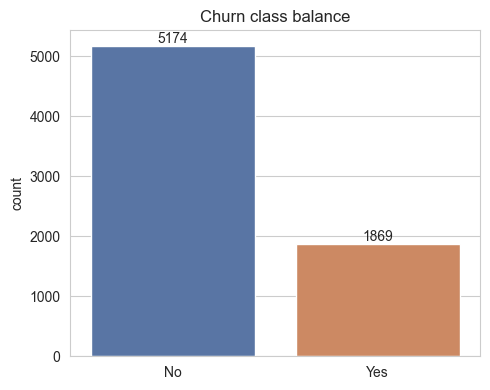

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="Churn", hue="Churn", palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)
ax.set_title("Churn class balance")
ax.set_xlabel("")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()


About 1 in 4 customers churned, not wildly imbalanced, but enough that plain accuracy
would be a lazy metric. We'll lean on ROC-AUC and F1 too, and give `class_weight='balanced'`
a shot in the grid search.

## 3. Clean + encode

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)  # blank = brand new customer = 0 spent so far, not "missing"

df = df.drop(columns=["customerID"])  # unique per row, pure noise for a model

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df.isna().sum().sum()  # sanity check, should be 0 after the fillna above


np.int64(0)

## 4. A couple of quick sanity-check plots

Before building anything, worth eyeballing what actually separates churners from non-churners.

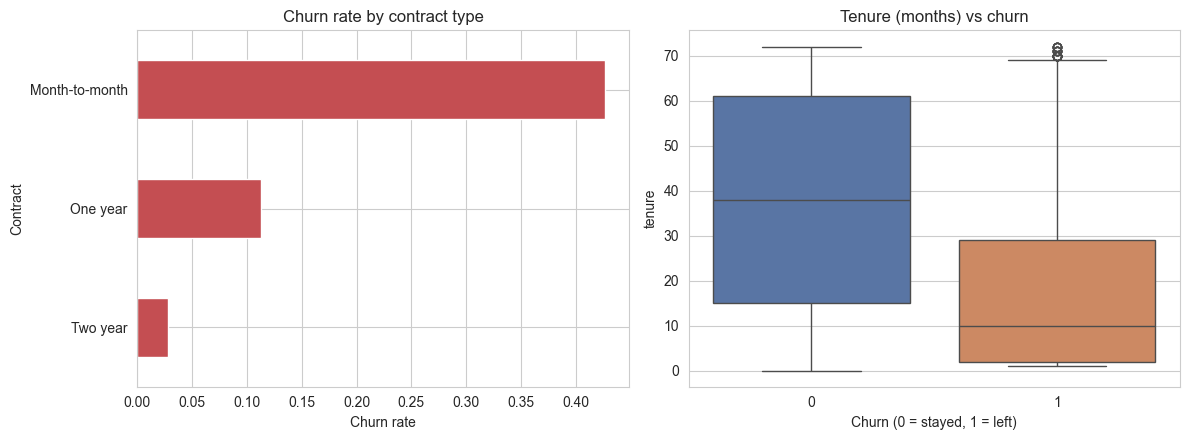

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

contract_churn = df.groupby("Contract")["Churn"].mean().sort_values()
contract_churn.plot(kind="barh", ax=axes[0], color="#C44E52")
axes[0].set_title("Churn rate by contract type")
axes[0].set_xlabel("Churn rate")

sns.boxplot(data=df, x="Churn", y="tenure", hue="Churn", palette=["#4C72B0", "#DD8452"], legend=False, ax=axes[1])
axes[1].set_title("Tenure (months) vs churn")
axes[1].set_xlabel("Churn (0 = stayed, 1 = left)")

plt.tight_layout()
plt.show()


Month-to-month contracts churn way more than one/two-year contracts, and churners
skew heavily toward low tenure.

## 5. Train/test split + feature groups

In [9]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

# SeniorCitizen is already 0/1 so it behaves like a numeric flag, everything else
# that isn't clearly numeric goes to the categorical bucket
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_features = [c for c in X.columns if c not in numeric_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (5634, 19), Test: (1409, 19)


## 6. Build the pipelines

Preprocessing lives *inside* the pipeline object, so `.fit()` on train and
`.predict()` on test (or on brand-new data later) can never leak information 
or drift out of sync.

In [10]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    # drop='if_binary' collapses the truly two-valued columns (gender, Partner, etc.) down
    # to a single column instead of two redundant ones
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
])

pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE)),
])


## 7. Hyperparameter tuning with GridSearchCV

Scoring on `roc_auc` instead of accuracy, with 73/27 class balance, accuracy rewards a
model for just guessing "no churn" a lot. Both grids include `class_weight='balanced'` as
an option so the search can decide for itself whether reweighting actually helps.

In [11]:
lr_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__class_weight": [None, "balanced"],
}

grid_lr = GridSearchCV(pipe_lr, lr_param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("Best LR params:", grid_lr.best_params_)
print("Best LR CV ROC-AUC:", round(grid_lr.best_score_, 4))


Best LR params: {'classifier__C': 10, 'classifier__class_weight': None}
Best LR CV ROC-AUC: 0.8459


In [12]:
rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__class_weight": [None, "balanced"],
}

grid_rf = GridSearchCV(pipe_rf, rf_param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best RF params:", grid_rf.best_params_)
print("Best RF CV ROC-AUC:", round(grid_rf.best_score_, 4))


Best RF params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best RF CV ROC-AUC: 0.8441


## 8. Evaluate on the held-out test set

In [13]:
def evaluate(name, model, X_test, y_test):
    # one function so LR and RF get scored identically — no copy-pasted metric calls to typo
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, proba),
    }

results = [
    evaluate("Logistic Regression", grid_lr.best_estimator_, X_test, y_test),
    evaluate("Random Forest", grid_rf.best_estimator_, X_test, y_test),
]

results_df = pd.DataFrame(results).set_index("model").round(4)
results_df


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.8048,0.6552,0.5588,0.6032,0.8413
Random Forest,0.7551,0.5272,0.7513,0.6196,0.8390


In [14]:
print(classification_report(y_test, grid_lr.best_estimator_.predict(X_test),
                             target_names=["No churn", "Churn"]))


              precision    recall  f1-score   support

    No churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



## 9. Visualize the results

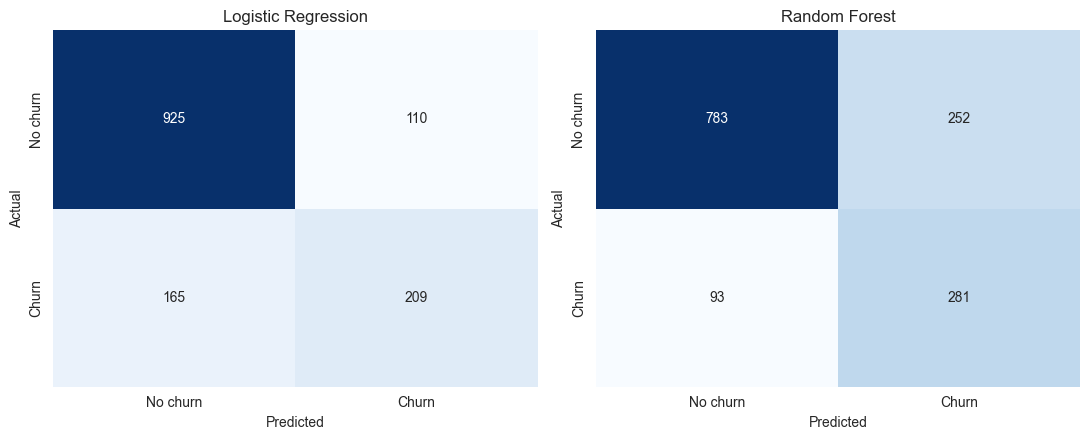

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, model) in zip(axes, [("Logistic Regression", grid_lr.best_estimator_),
                                     ("Random Forest", grid_rf.best_estimator_)]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No churn", "Churn"], yticklabels=["No churn", "Churn"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


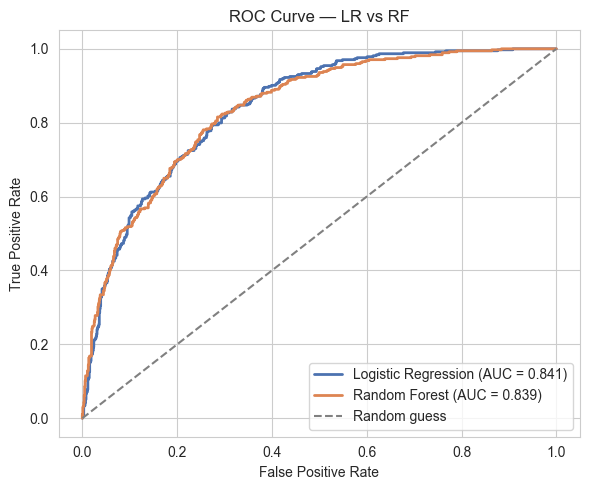

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))

for name, model, color in [("Logistic Regression", grid_lr.best_estimator_, "#4C72B0"),
                            ("Random Forest", grid_rf.best_estimator_, "#DD8452")]:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — LR vs RF")
ax.legend()
plt.tight_layout()
plt.show()


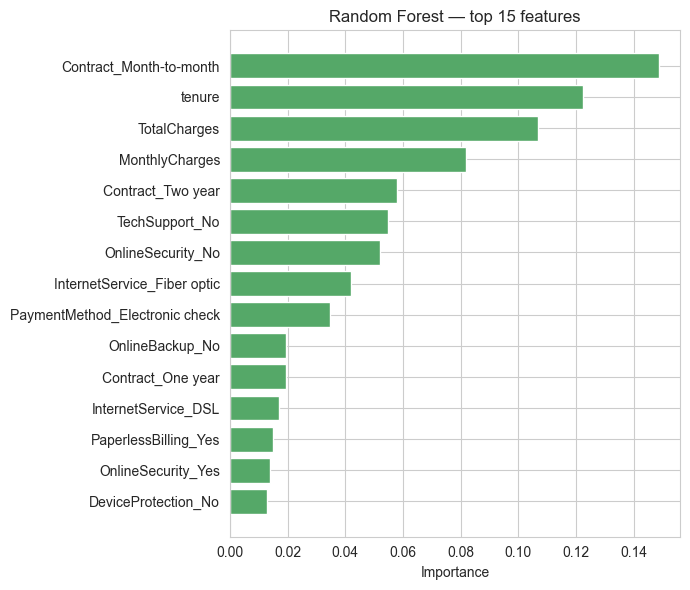

In [17]:
# feature names only exist after the preprocessor has been fit, so pull them from the fitted pipeline
feature_names = grid_rf.best_estimator_.named_steps["preprocessor"].get_feature_names_out()
importances = grid_rf.best_estimator_.named_steps["classifier"].feature_importances_

top_n = 15
top_idx = np.argsort(importances)[-top_n:]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(range(top_n), importances[top_idx], color="#55A868")
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i].split("__")[-1] for i in top_idx])
ax.set_xlabel("Importance")
ax.set_title(f"Random Forest — top {top_n} features")
plt.tight_layout()
plt.show()


## 10. Picking a model

Logistic Regression edges out Random Forest on accuracy, precision, and ROC-AUC, and it's
the simpler, more interpretable, faster-to-serve option. Random Forest catches more
churners (higher recall) at the cost of more false alarms. We'll choose Logistic Regression 
as the default, but both are saved so the choice can be revisited.

In [18]:
best_name = results_df["roc_auc"].idxmax()
best_model = grid_lr.best_estimator_ if best_name == "Logistic Regression" else grid_rf.best_estimator_
print(f"Exporting: {best_name}")

joblib.dump(best_model, "churn_pipeline.joblib")
joblib.dump(grid_rf.best_estimator_, "churn_pipeline_rf_backup.joblib")  # keeping the runner-up around too


Exporting: Logistic Regression


['churn_pipeline_rf_backup.joblib']

In [21]:
# reload from disk and confirm it predicts without any of the original preprocessing code around —
# this is the actual point of exporting a Pipeline instead of a bare model
reloaded = joblib.load("churn_pipeline.joblib")

sample = X_test.iloc[:5]
print("Predictions:", reloaded.predict(sample).tolist())
print("Actuals:    ", y_test.iloc[:5].tolist())


Predictions: [0, 1, 0, 0, 0]
Actuals:     [0, 0, 0, 0, 0]


## Summary

- **Best model:** Logistic Regression (tuned `C`, no class weighting needed),
  **ROC-AUC ≈ 0.84**, accuracy ≈ 0.80 on the held-out test set.
- **Random Forest** came in close behind on AUC (≈ 0.84) but with notably higher recall,
  worth a second look if the business priority is "catch every possible churner" over
  "minimize false alarms."
- **What causes churn:** contract type dominates, month-to-month customers
  churn far more than customers on 1–2 year contracts, followed by tenure (new customers
  are flight risks) and monthly charges (pricier plans churn more). Add-on services like
  tech support and online security correlate with *lower* churn, which reads like an
  engagement signal: customers who are more "hooked in" to the ecosystem stick around.
- **Practically:** the exported `churn_pipeline.joblib` is a single self-contained object,
  raw customer rows in, churn predictions out.